In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Cargar datos
df = pd.read_csv("C:/Users/Franco/Desktop/Programas/Python DataScience/Machine Learning/Ventas (1).csv")

# Convertir fecha
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Crear variables útiles desde la fecha
df["Mes"] = df["Fecha"].dt.month
df["Año"] = df["Fecha"].dt.year

# Eliminar columna fecha (opcional si no se usa como serie temporal)
df = df.drop("Fecha", axis=1)

# Manejo de faltantes
df = df.dropna()

# Variables
X = df.drop("Ventas", axis=1)
y = df["Ventas"]

# Convertir categóricas
X = pd.get_dummies(X, columns=["DíaDeLaSemana"], drop_first=True)

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
df.head()

,DíaDeLaSemana,Promociones,Festivo,Ventas,Mes,Año
0,6,0,0,4033,1,2022
1,7,0,1,4012,1,2022
2,1,0,0,1608,1,2022
3,2,1,0,2046,1,2022
4,3,0,0,2484,1,2022


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DíaDeLaSemana  365 non-null    int64
 1   Promociones    365 non-null    int64
 2   Festivo        365 non-null    int64
 3   Ventas         365 non-null    int64
 4   Mes            365 non-null    int32
 5   Año            365 non-null    int32
dtypes: int32(2), int64(4)
memory usage: 14.4 KB


# ANALISIS EXPLORATORIO

In [36]:
df.describe()

,DíaDeLaSemana,Promociones,Festivo,Ventas,Mes,Año
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.0
mean,4.005479,0.200000,0.142466,2997.219178,6.526027,2022.0
std,2.002738,0.400549,0.350007,942.096284,3.452584,0.0
min,1.000000,0.000000,0.000000,1305.000000,1.000000,2022.0
25%,2.000000,0.000000,0.000000,2195.000000,4.000000,2022.0
50%,4.000000,0.000000,0.000000,3074.000000,7.000000,2022.0
75%,6.000000,0.000000,0.000000,3979.000000,10.000000,2022.0
max,7.000000,1.000000,1.000000,4404.000000,12.000000,2022.0


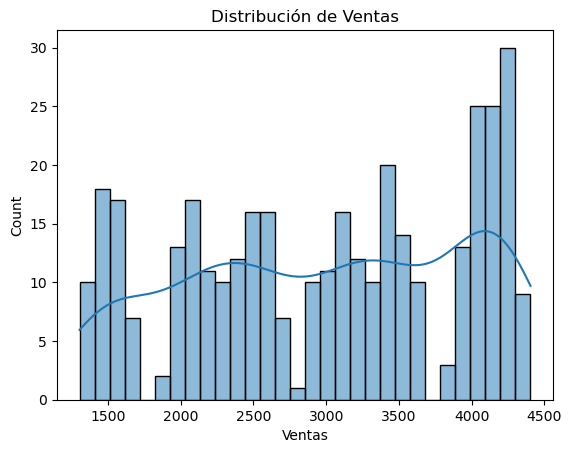

In [32]:
# Distribución de ventas
sns.histplot(df["Ventas"], bins=30, kde=True)
plt.title("Distribución de Ventas")
plt.show()

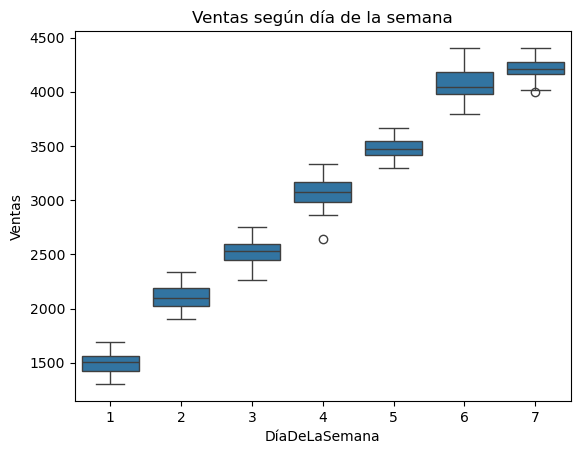

In [8]:
# Ventas por día de la semana
sns.boxplot(x="DíaDeLaSemana", y="Ventas", data=df)
plt.title("Ventas según día de la semana")
plt.show()

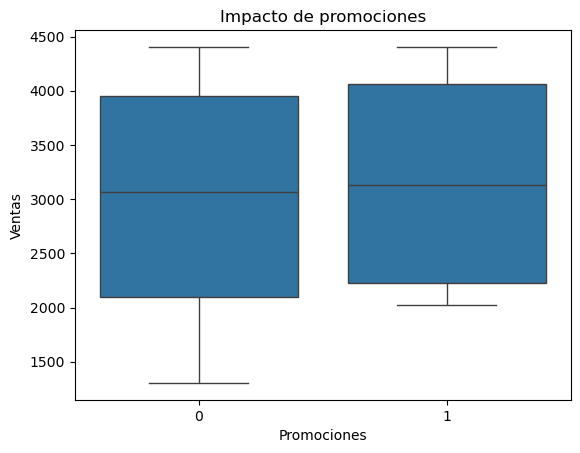

In [9]:
# Promociones vs ventas
sns.boxplot(x="Promociones", y="Ventas", data=df)
plt.title("Impacto de promociones")
plt.show()

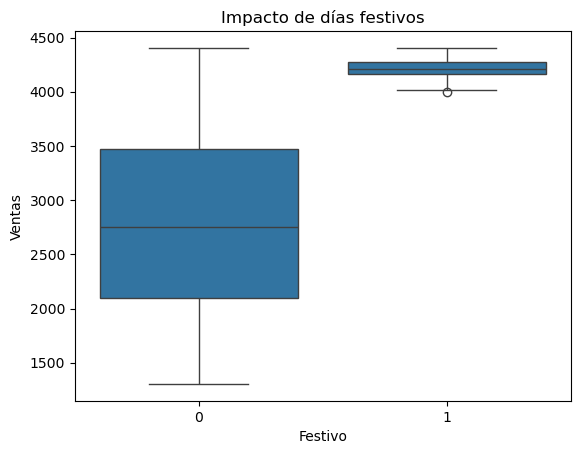

In [10]:
# Festivos vs ventas
sns.boxplot(x="Festivo", y="Ventas", data=df)
plt.title("Impacto de días festivos")
plt.show()

# CONCLUSIONES DEL ANALISIS EXPLORATORIO

## 
1) TABLA DESCRIPTIVA:
   Evaluando los puntos minimos, maximos y desvios se puede ver que existe una gran variabilidad en las ventas diarias, en donde el 25% de los dias tienen ventas relativamente bajas mientras que el 75% poseen ventas mas altas.
2) VENTAS POR DIA DE LA SEMANA:
   En el grafico podemos notar que existe una tendencia creciente en las ventas de Lunes a Domingo dado que la gente tiende a consumir a medida que llega el fin de semana.
   Ademas los errores estandar y variabilidad de cada dia tienen valores bajos, por lo que las ventas dependiendo el dia son muy consistentes semana a semana, es decir, se repiten con poca variacion.
3) IMPACTO DE PROMOCIONES
   Los días sin promociones poseen una mediana mas baja y una gran 
variabilidad en venta mientras que los dias que si poseen promociones aumentan la mediana pero mejoran significativamente la variabilidad de ventas, es decir, la mediana de ventas tiene un leve aumento pero el principal impacto se genera con la variabilidad de ventas mejorandolas positivamente.
4) IMPACTO DE DIAS FESTIVOS
   Los dias festivos tienen un efecto muy positivo en las ventas, la mediana aumenta de manera significativa y ademas la variabilidad es muy baja, por lo que los dias festivo son dias que generalmente aseguran una gran cantidad de ventas.
5) COMPARACION DIAS FESTIVOS Y PROMOCIONES
   Las promociones poseen un impacto positivo en las ventas 
pero el efecto producido por los dias festivos tiene un imapact 
mucho mayor y positivo para la tien.das

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# Modelos a evaluar
models = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predecir
    y_pred = model.predict(X_test)
    
    # Métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mse, r2])

# Mostrar resultados
results_df = pd.DataFrame(results, columns=["Modelo", "MSE", "R2"])
print(results_df)

              Modelo           MSE        R2
0   Regresión Lineal   7392.565762  0.992471
1  Árbol de Decisión  10164.669045  0.989647
2      Random Forest   9544.368828  0.990279


In [12]:
modelo = LinearRegression()

In [13]:
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [14]:
print("MSE final:", mean_squared_error(y_test, y_pred))
print("R2 final:", r2_score(y_test, y_pred))

MSE final: 7392.565762468802
R2 final: 0.9924706229039881


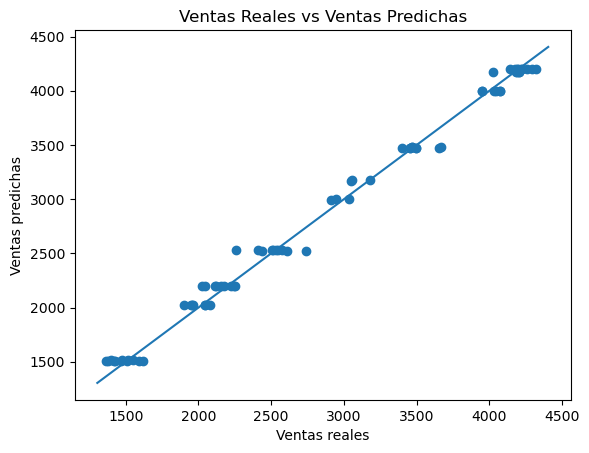

In [44]:
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Ventas Reales vs Ventas Predichas")
plt.show()

In [16]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

print(coeficientes.sort_values(by="Coeficiente", ascending=False))

          Variable   Coeficiente
8  DíaDeLaSemana_6  2.487436e+03
7  DíaDeLaSemana_5  1.965317e+03
6  DíaDeLaSemana_4  1.488565e+03
1          Festivo  1.345549e+03
9  DíaDeLaSemana_7  1.345549e+03
5  DíaDeLaSemana_3  1.017795e+03
4  DíaDeLaSemana_2  5.151284e+02
0      Promociones  1.747238e+02
2              Mes  3.972746e-01
3              Año -9.094947e-13


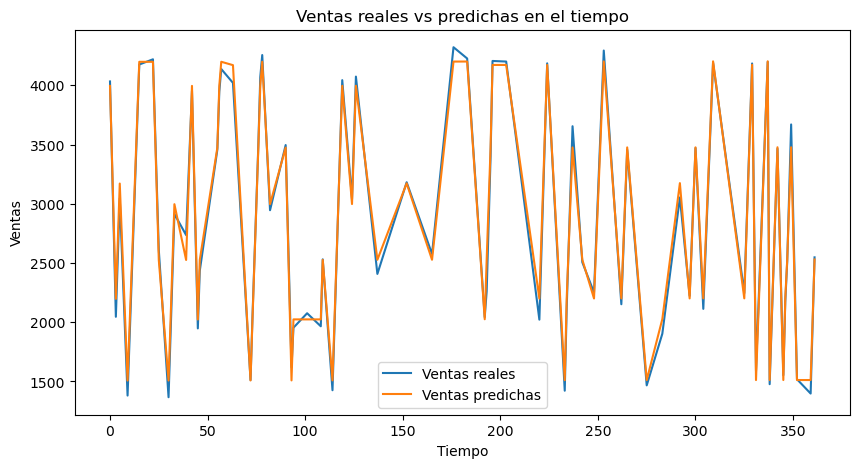

In [17]:
# Asegurarse de mantener índice alineado
resultados = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred
})

# Ordenar por índice (que suele venir de la fecha)
resultados = resultados.sort_index()

plt.figure(figsize=(10,5))
plt.plot(resultados["Real"], label="Ventas reales")
plt.plot(resultados["Predicho"], label="Ventas predichas")

plt.title("Ventas reales vs predichas en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Ventas")
plt.legend()

plt.show()

# CONCLUSIÓN 

1) El primer gráfico muestra un diagrama de dispersión de las Ventas Reales vs Ventas Predichas, sugiere que el modelo de regresión lineal utilizado puede predecir con buenos las ventas. La línea de tendencia indica una fuerte relación positiva entre los valores reales y predichos, lo que significa que puede capturar la tendencia de las ventas con eficacia.
2) El segundo gráfico nos muestra las Ventas reales vs predichas en el tiempo, donde podemos ver que en gran parte del grafico hay gran similitud con los valores reales, aunque existen puntos en donde la diferencia es significativa. Estas diferencias pueden provenir de eventos externos o internos no capturados, o simplemente una variacion natural en ventas que no es predecible.

## RECOMENDACIONES

##
1) Manejo del Inventario:
    Utilizando las predicciones y analisis exploratorio, pretender que el stock de los ultimos dias de la semana sea bastante mayor al de los primeros dias. Ademas agregar stock adicional en los dias festivos que en linea general tienen muchas mas ventas.
2) Planificacion de Personal:
   Ajustar los horarios para tener mayor personal los dias del fin de semana y los dias festivos, y no necesariamente por dias de promociones.
3) Marketing Objetivo:
   Se pueden dirigir campañas de marketing basandose mas en las ventas de fin de semana y dias festivos. Si las promociones no poseen tanto marketing puede que eso sea la respuesta de porque no generan tantos cambios como si lo hacen los dias festivos.
4) Analisis de Anomalias:
   En aquellos puntos en donde el modelo predicho difiere significativamente del modelo real se pueden realizar investigaciones de factores externos como situaciones economicas generales, eventos de la localidad y factores climaticos.
ima.